# Series temporales: actividad solar y temperatura global
## Sunspot Numbers SILSO + Anomalías Berkeley Earth

**Autor:** Jheison Martinez Bolivar
**Maestría:** Inteligencia Artificial
**Fecha:** Septiembre 2026
**Dataset:** [Sunspot Numbers 1700-2025 - Kaggle](https://www.kaggle.com/datasets/gallo33henrique/sunspot-numbers-dataset-17002025) + [Global Land Temperature Anomalies 1880-2024 - Kaggle](https://www.kaggle.com/datasets/adarshsalukhe/global-land-temperature-anomalies-1880-2024)

---

### Planteamiento del Proyecto
Este cuaderno trabaja dos series mensuales que se solapan desde 1880: el conteo de manchas solares del observatorio SILSO y las anomalías de temperatura global de Berkeley Earth.

Cada fila es un mes. La pregunta es si la actividad del Sol aporta señal para predecir la temperatura de la Tierra: comparo ARIMA sin exógena contra ARIMAX con manchas, y LSTM univariada contra LSTM multivariada, sobre el mismo corte temporal.

Las preguntas de investigación se fijan después del EDA.


In [1]:
%pip install -q kagglehub statsmodels gymnasium

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 110


/home/jheisonmblivecom/Academic/Deriverables/ML/series-temporales-prediccion/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sun_dir = Path(kagglehub.dataset_download('gallo33henrique/sunspot-numbers-dataset-17002025'))
tmp_dir = Path(kagglehub.dataset_download('adarshsalukhe/global-land-temperature-anomalies-1880-2024'))
sun_path = sun_dir / 'SN_m_tot_V2.0.csv'
tmp_path = next(tmp_dir.glob('Global_Land_Temperature_Anomalies_*.csv'))

sun_cols = ['year', 'month', 'decimal_date', 'sunspots', 'sunspots_std', 'n_obs', 'flag']
sun_raw = pd.read_csv(sun_path, sep=';', header=None, names=sun_cols)
tmp_raw = pd.read_csv(tmp_path)

print(f'Ruta manchas: {sun_path}')
print(f'Ruta temperatura: {tmp_path}')
print(f'Filas y columnas en bruto: manchas {sun_raw.shape}, temperatura {tmp_raw.shape}')
print()
print('Tipos de datos:')
print(pd.DataFrame({'manchas': sun_raw.dtypes.astype(str), 'temperatura': tmp_raw.dtypes.astype(str)}).to_string())
print()
print('Valores nulos por columna:')
print(pd.DataFrame({'manchas': sun_raw.isna().sum(), 'temperatura': tmp_raw.isna().sum()}).to_string())
print()
print('Primeros registros de manchas:')
display(sun_raw.head())
print('Primeros registros de temperatura:')
display(tmp_raw.head())


Ruta manchas: /home/jheisonmblivecom/.cache/kagglehub/datasets/gallo33henrique/sunspot-numbers-dataset-17002025/versions/1/SN_m_tot_V2.0.csv
Ruta temperatura: /home/jheisonmblivecom/.cache/kagglehub/datasets/adarshsalukhe/global-land-temperature-anomalies-1880-2024/versions/1/Global_Land_Temperature_Anomalies_(18802024).csv
Filas y columnas en bruto: manchas (3323, 7), temperatura (1757, 3)

Tipos de datos:
              manchas temperatura
decimal_date  float64         NaN
flag            int64         NaN
land              NaN     float64
month           int64         NaN
n_obs           int64         NaN
station           NaN     float64
sunspots      float64         NaN
sunspots_std  float64         NaN
time              NaN     float64
year            int64         NaN

Valores nulos por columna:
              manchas  temperatura
decimal_date      0.0          NaN
flag              0.0          NaN
land              NaN          0.0
month             0.0          NaN
n_obs       

,year,month,decimal_date,sunspots,sunspots_std,n_obs,flag
0,1749,1,1749.042,96.7,-1.0,-1,1
1,1749,2,1749.123,104.3,-1.0,-1,1
2,1749,3,1749.204,116.7,-1.0,-1,1
3,1749,4,1749.288,92.8,-1.0,-1,1
4,1749,5,1749.371,141.7,-1.0,-1,1


Primeros registros de temperatura:


,time,station,land
0,1880.04,-0.32,-0.19
1,1880.13,-0.52,-0.25
2,1880.21,-0.37,-0.10
3,1880.29,-0.58,-0.17
4,1880.38,-0.28,-0.10


## Qué trae cada archivo

Ahora sí, con los archivos ya cargados arriba:

**Manchas solares** — conteo mensual total SILSO, versión 2.0. El archivo no trae encabezado y usa `;` como separador.

| columna | qué es |
|---|---|
| `year`, `month` | año y mes calendario |
| `decimal_date` | fecha decimal, punto medio del mes |
| `sunspots` | promedio mensual del número de manchas |
| `sunspots_std` | dispersión entre observadores (-1 cuando no aplica) |
| `n_obs` | días observados en el mes (-1 en serie histórica) |
| `flag` | 1 definitivo, 0 provisional |

**Temperatura** — anomalías mensuales Berkeley Earth. Una anomalía no es la temperatura en grados, es la desviación de ese mes respecto a su referencia climática (lo habitual es la media 1951-1980): +0.5 significa medio grado por encima de lo normal para ese mes, -0.3 por debajo.

| columna | qué es |
|---|---|
| `time` | año decimal (1880.04 es enero de 1880) |
| `station` | anomalía combinada tierra y océano, más suave |
| `land` | anomalía solo sobre tierra, con más amplitud, la protagonista |

Me quedo con `land` porque el océano amortigua y suaviza: la señal terrestre responde más rápido y deja más estructura para predecir.


In [4]:
sun = sun_raw.copy()
sun['date'] = pd.to_datetime(dict(year=sun.year, month=sun.month, day=1))
sun = sun.set_index('date').sort_index()

tmp = tmp_raw.copy()
tmp_year = tmp['time'].astype(int)
tmp_month = ((tmp['time'] - tmp_year) * 12).astype(int) + 1
tmp_month = tmp_month.clip(1, 12)
tmp['date'] = pd.to_datetime(dict(year=tmp_year, month=tmp_month, day=1))
tmp = tmp.set_index('date').sort_index()

start = '1880-01-01'
sun_m = sun.loc[start:, ['sunspots']].copy()
tmp_m = tmp.loc[start:, ['station', 'land']].copy()
frame = tmp_m.join(sun_m, how='inner')

full_idx = pd.date_range(frame.index.min(), frame.index.max(), freq='MS')
missing = full_idx.difference(frame.index)

print('Rango común:')
print(f'{frame.index.min().date()} a {frame.index.max().date()}, n={len(frame)}')
print()
print('Meses faltantes:', len(missing))
print('Fechas duplicadas:', frame.index.duplicated().sum())
print('Filas totalmente duplicadas:', frame.duplicated().sum())
print()
print('Resumen de las tres columnas:')
display(frame[['station', 'land', 'sunspots']].describe().round(2))


Rango común:
1880-01-01 a 2025-11-01, n=1751

Meses faltantes: 0
Fechas duplicadas: 0
Filas totalmente duplicadas: 0

Resumen de las tres columnas:


,station,land,sunspots
count,1751.00,1751.00,1751.00
mean,0.11,0.08,83.60
std,0.52,0.41,67.97
min,-1.44,-0.82,0.00
25%,-0.23,-0.22,24.50
50%,-0.01,-0.03,70.90
75%,0.36,0.31,126.90
max,1.85,1.48,359.40


## Las dos series en nivel

Parto de una intuición: la temperatura trae tendencia creciente con oscilación anual, y las manchas traen ciclos amplios sin tendencia. Si el gráfico muestra eso, el siguiente paso es cuantificarlo (tendencia por décadas, ciclo dominante del sol); si no, corrijo la intuición antes de modelar.


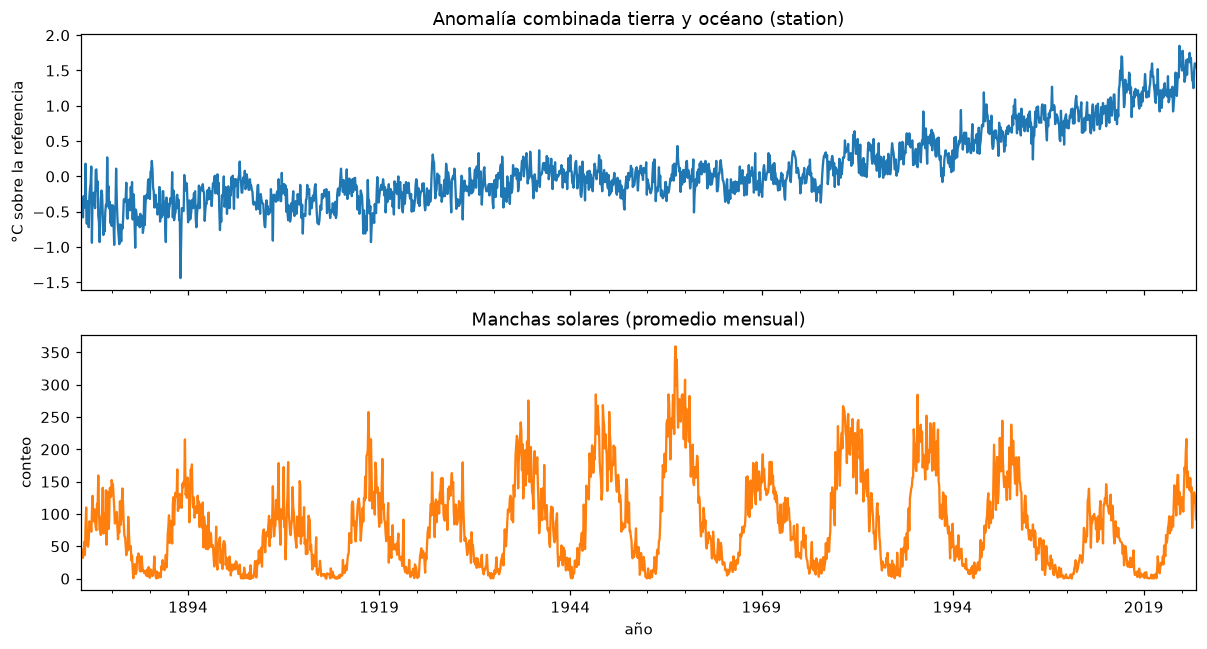

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
frame['station'].plot(ax=axes[0])
axes[0].set_title('Anomalía combinada tierra y océano (station)')
axes[0].set_ylabel('°C sobre la referencia')
axes[0].set_xlabel('')
frame['sunspots'].plot(ax=axes[1], color='tab:orange')
axes[1].set_title('Manchas solares (promedio mensual)')
axes[1].set_ylabel('conteo')
axes[1].set_xlabel('año')
fig.tight_layout()
plt.show()


## Land contra station: con cuál me quedo

Parto de una intuición: el impacto solar es mundial y el océano es la mayor parte del mundo, así que quiero ver las dos y compararlas con números. Si la tabla muestra diferencias claras en dispersión, tendencia por década y correlación con manchas, fijo la protagonista con esa evidencia.


In [6]:
decade = (frame.index.year // 10 * 10).astype(str) + 's'
decadal = frame.groupby(decade)[['station', 'land']].mean().round(3)
decadal['delta_land'] = decadal['land'].diff().round(3)
decadal['delta_station'] = decadal['station'].diff().round(3)

print('Medias por década con cambio respecto a la década anterior:')
display(decadal)

summary = pd.DataFrame({
    'std_total': frame[['station', 'land']].std().round(3),
    'corr_con_manchas': frame[['station', 'land']].corrwith(frame['sunspots']).round(3),
})
print('Dispersión total y correlación mensual con manchas:')
display(summary)


Medias por década con cambio respecto a la década anterior:


,station,land,delta_land,delta_station
date,,,,
1880s,-0.416,-0.216,NaN,NaN
1890s,-0.357,-0.239,-0.023,0.059
1900s,-0.309,-0.317,-0.078,0.048
1910s,-0.328,-0.334,-0.017,-0.019
1920s,-0.210,-0.241,0.093,0.118
1930s,-0.064,-0.123,0.118,0.146
1940s,0.008,0.043,0.166,0.072
1950s,-0.052,-0.048,-0.091,-0.060
1960s,-0.040,-0.030,0.018,0.012


Dispersión total y correlación mensual con manchas:


,std_total,corr_con_manchas
station,0.520,0.018
land,0.414,0.026


### Cierre

Con los datos en la mano, `station` trae más dispersión que `land` (std 0.52 contra 0.41) y saltos por década mayores; `land` es la serie suave. La correlación mensual con manchas da ~cero en ambas, así que no hay vínculo instantáneo que decida. Fijo `land` como protagonista: es la serie limpia del dataset y su suavidad beneficia al modelo.


## Descomposición de land: tendencia y ciclo anual

Parto de una intuición: `land` trae una tendencia creciente que domina y quizás un resto anual por las estaciones.

Cómo se calcula, paso a paso. Primero la tendencia: cada punto es el promedio de sus doce meses vecinos, así se borra lo mensual y queda lo lento. Segundo, la serie sin tendencia: a cada mes le resto su tendencia y queda lo que oscila alrededor de cero. Tercero, la estacionalidad: junto todos los eneros sin tendencia y los promedio, luego todos los febreros, y así con los doce meses. Esos doce promedios son el componente estacional, y por construcción se repite idéntico todos los años: hay un solo enero para todo el período, no uno por década.


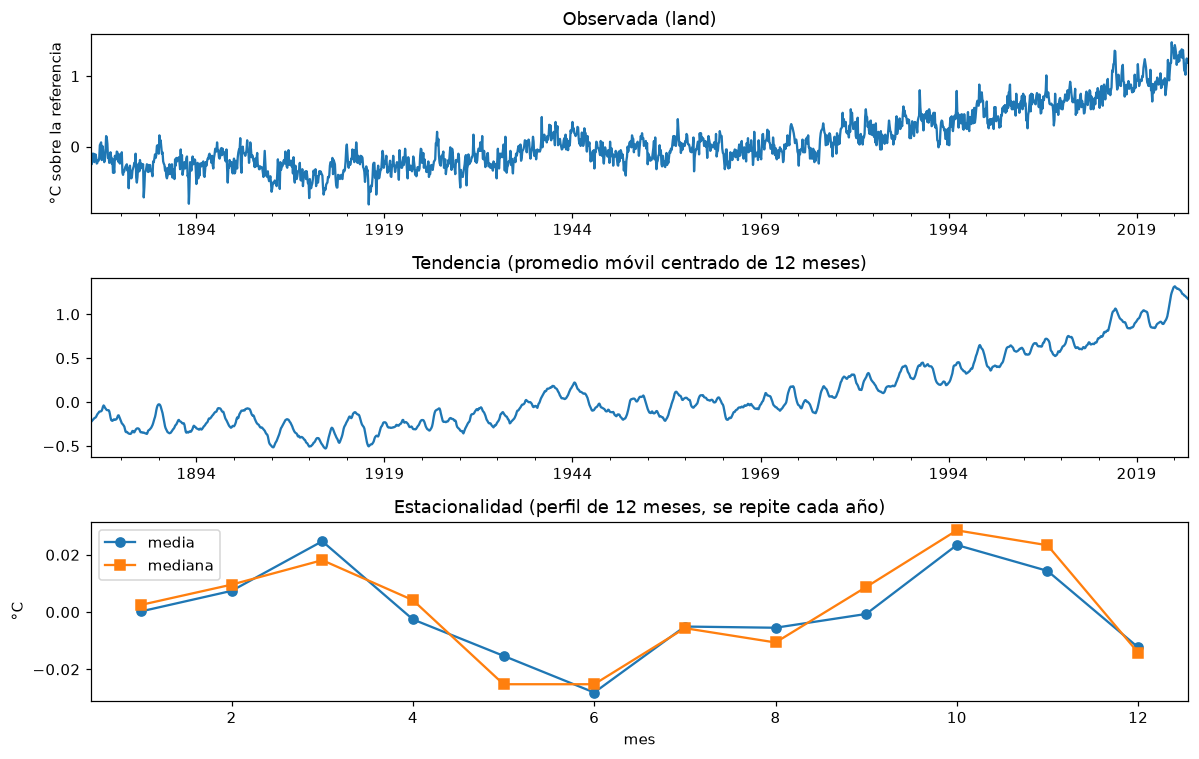

Perfil estacional por mes, media contra mediana:


,media,mediana
date,,
1,0.000,0.003
2,0.007,0.010
3,0.025,0.018
4,-0.003,0.004
5,-0.015,-0.025
6,-0.028,-0.025
7,-0.005,-0.006
8,-0.005,-0.011
9,-0.001,0.009


Dispersión de land por década:


,std_land
date,
1880s,0.151
1890s,0.137
1900s,0.165
1910s,0.165
1920s,0.130
1930s,0.138
1940s,0.140
1950s,0.141
1960s,0.126


In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(frame['land'], model='additive', period=12, extrapolate_trend='freq')
detrended = frame['land'] - decomposition.trend
seasonal_mean = detrended.groupby(frame.index.month).mean()
seasonal_median = detrended.groupby(frame.index.month).median()
decade = (frame.index.year // 10 * 10).astype(str) + 's'
decadal_spread = frame.groupby(decade)['land'].std().round(3).to_frame('std_land')

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=False)
frame['land'].plot(ax=axes[0])
axes[0].set_title('Observada (land)')
axes[0].set_ylabel('°C sobre la referencia')
axes[0].set_xlabel('')
decomposition.trend.plot(ax=axes[1])
axes[1].set_title('Tendencia (promedio móvil centrado de 12 meses)')
axes[1].set_xlabel('')
seasonal_mean.plot(ax=axes[2], marker='o', label='media')
seasonal_median.plot(ax=axes[2], marker='s', label='mediana')
axes[2].set_title('Estacionalidad (perfil de 12 meses, se repite cada año)')
axes[2].set_ylabel('°C')
axes[2].set_xlabel('mes')
axes[2].legend()
fig.tight_layout()
plt.show()

print('Perfil estacional por mes, media contra mediana:')
display(pd.DataFrame({'media': seasonal_mean.round(3), 'mediana': seasonal_median.round(3)}))
print('Dispersión de land por década:')
display(decadal_spread)


### Cierre

Es mi interpretación que sí hay una forma anual visible: en promedio los marzo y octubre traen las anomalías más altas y junio las más bajas. Pero no la leo como estaciones de ningún hemisferio, porque cada anomalía se compara contra la referencia de su propio mes y el contraste entre estaciones ya no está en el dato. Medí también con mediana en vez de media y cuenta lo mismo, así que no depende del promedio elegido. Y la dispersión por década crece en las últimas décadas: las anomalías no solo suben, se mueven más.


## El ciclo del sol: mido los máximos uno por uno

Parto de una intuición: las manchas suben y bajan en ciclos de unos once años, y eso se ve a ojo en el primer gráfico.

Cómo lo mido sin cajas negras: suavizo la serie con el mismo promedio móvil de trece meses que usa el SILSO, marco los máximos separados por varios años y calculo cuántos meses pasan entre un máximo y el siguiente. La tabla de intervalos dice si el ciclo es regular y de cuánto.


Máximos encontrados: 14


date,1894-01,1906-01,1917-07,1926-11,1937-04,1947-05,1958-03,1968-11,1979-12,1989-06,2002-03,2014-04,2024-10
meses_entre_maximos,121.0,144.0,137.9,112.0,125.0,121.0,130.0,128.1,133.0,114.0,153.0,145.0,126.0


Intervalo medio entre máximos: 130 meses


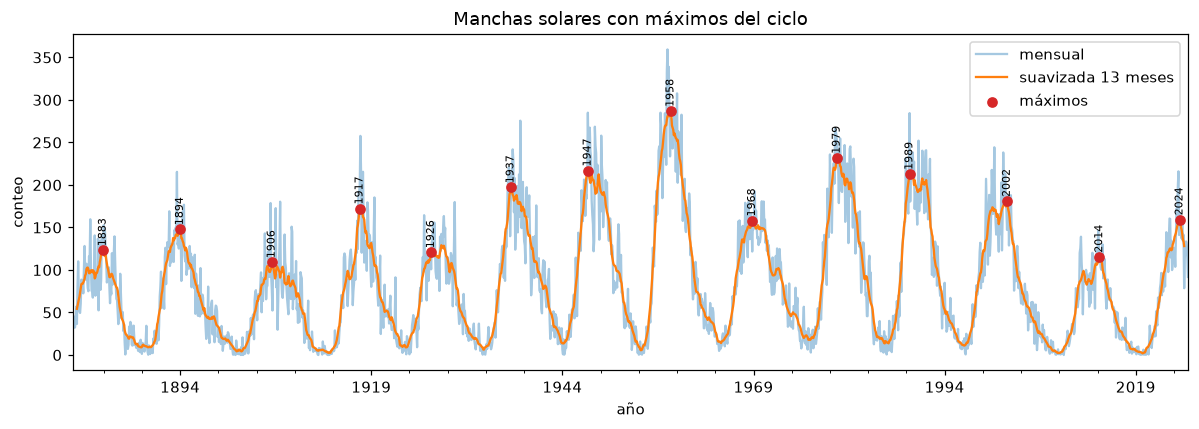

In [8]:
from scipy.signal import find_peaks

smoothed = frame['sunspots'].rolling(13, center=True).mean()
peaks, _ = find_peaks(smoothed, distance=110)
maxima = frame.index[peaks]
gaps = pd.Series(maxima[1:] - maxima[:-1]).dt.days.div(30.44).round(1).to_frame('meses_entre_maximos')
gaps.index = maxima[1:].strftime('%Y-%m')

print(f'Máximos encontrados: {len(maxima)}')
display(gaps.T)
print(f'Intervalo medio entre máximos: {gaps["meses_entre_maximos"].mean():.0f} meses')

fig, ax = plt.subplots(figsize=(11, 4))
frame['sunspots'].plot(ax=ax, alpha=0.4, label='mensual')
smoothed.plot(ax=ax, label='suavizada 13 meses')
ax.scatter(maxima, smoothed.loc[maxima], color='tab:red', zorder=5, label='máximos')
for stamp in maxima:
    ax.text(stamp, smoothed.loc[stamp] + 8, stamp.strftime('%Y'), fontsize=7, ha='center', rotation=90)
ax.set_title('Manchas solares con máximos del ciclo')
ax.set_ylabel('conteo')
ax.set_xlabel('año')
ax.legend()
fig.tight_layout()
plt.show()


### Cierre

Es mi interpretación que el ciclo se ve a ojo y se deja medir: marco los máximos de la serie suavizada, exigiendo casi una década entre uno y otro porque cada máximo trae picos dobles que no son ciclos nuevos. La tabla de intervalos muestra ciclos de duración parecida alrededor de la decena de años, con variación natural entre uno y otro.


## Preguntas de investigación

Fijadas después del EDA:

- **P1.** ¿La temperatura se predice con su propio pasado? (ARIMA sobre `land`.)
- **P2.** ¿Las manchas aportan señal? (ARIMAX con `sunspots` contra el ARIMA de P1, mismo corte.)
- **P3.** ¿La LSTM aprovecha mejor la exógena? (LSTM univariada y multivariada contra lo estadístico.)

Bloque aparte: el agente de control continuo y el péndulo.


## Corte temporal: entreno hasta 2000, pruebo hacia adelante

El futuro no se mira: entreno con 1880-2000 y pruebo con 2001 en adelante, el mismo corte para los cuatro modelos. El test cubre un cuarto de siglo con más de dos ciclos solares y el calentamiento rápido, así que es una prueba dura. La validación de la LSTM saldrá de dentro del entreno, sin tocar el test.


Entreno: 1880-01-01 a 2000-12-01, n=1452
Prueba: 2001-01-01 a 2025-11-01, n=299


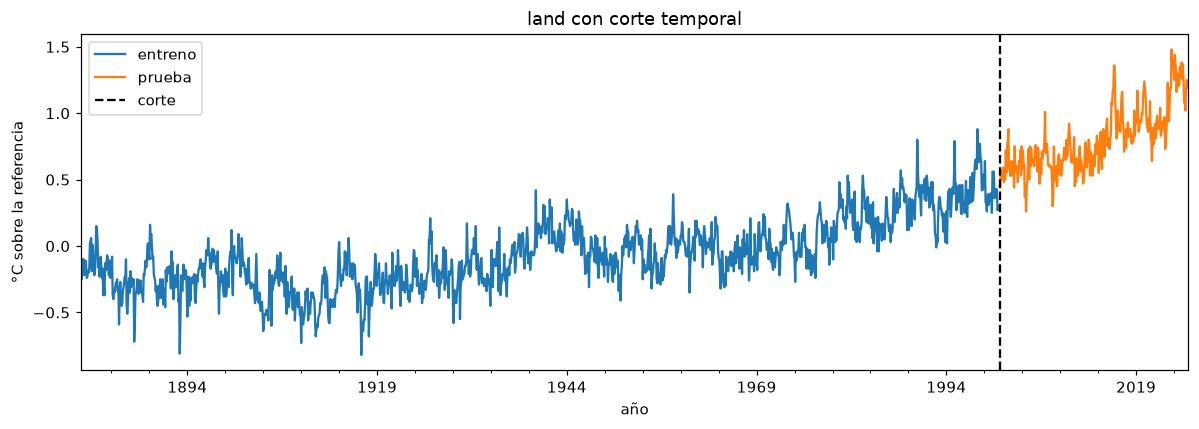

In [9]:
cutoff = '2001-01-01'
train = frame.loc[:'2000-12-01'].copy()
test = frame.loc[cutoff:].copy()

print(f'Entreno: {train.index.min().date()} a {train.index.max().date()}, n={len(train)}')
print(f'Prueba: {test.index.min().date()} a {test.index.max().date()}, n={len(test)}')

fig, ax = plt.subplots(figsize=(11, 4))
train['land'].plot(ax=ax, label='entreno')
test['land'].plot(ax=ax, label='prueba')
ax.axvline(pd.Timestamp(cutoff), color='black', linestyle='--', label='corte')
ax.set_title('land con corte temporal')
ax.set_ylabel('°C sobre la referencia')
ax.set_xlabel('año')
ax.legend()
fig.tight_layout()
plt.show()


## Estacionariedad formal: ADF en nivel y en diferencia

Parto de una intuición: `land` en nivel no es estacionaria porque su media va subiendo, y su primera diferencia sí lo es porque oscila alrededor de cero. Lo decido con el test ADF sobre el entreno, sin mirar la prueba.


In [10]:
from statsmodels.tsa.stattools import adfuller

level_stat, level_p, _, _, level_crit, _ = adfuller(train['land'].dropna())
diff_stat, diff_p, _, _, diff_crit, _ = adfuller(train['land'].diff().dropna())

verdict = pd.DataFrame({
    'estadistico': [level_stat, diff_stat],
    'p_valor': [level_p, diff_p],
    'critico_5pct': [level_crit['5%'], diff_crit['5%']],
}, index=['nivel', 'diferencia_1'])
display(verdict.round(4))
print('Nivel: ' + ('no estacionaria' if level_p > 0.05 else 'estacionaria'))
print('Diferencia 1: ' + ('no estacionaria' if diff_p > 0.05 else 'estacionaria'))


,estadistico,p_valor,critico_5pct
nivel,-1.7140,0.4239,-2.8636
diferencia_1,-11.4381,0.0000,-2.8636


Nivel: no estacionaria
Diferencia 1: estacionaria


### Cierre

Mi intuición se sostuvo: el nivel no pasa el test y la primera diferencia sí. Fijo `d=1` para el ARIMA, decidido solo con el entreno.


## Órdenes p y q: qué pasado pesa

Parto de una intuición: después de diferenciar, la temperatura de un mes todavía se parece a sus meses vecinos, y esa memoria se apaga con los rezagos. La autocorrelación (ACF) mide el parecido directo con cada rezago y la parcial (PACF) el parecido que queda al quitar los rezagos intermedios: el corte de la PACF sugiere el `p` y el de la ACF el `q`.

Cómo leer los dos gráficos de abajo: cada barra es un rezago en meses y la banda azul es el umbral de ruido; lo que sobresale es memoria real.


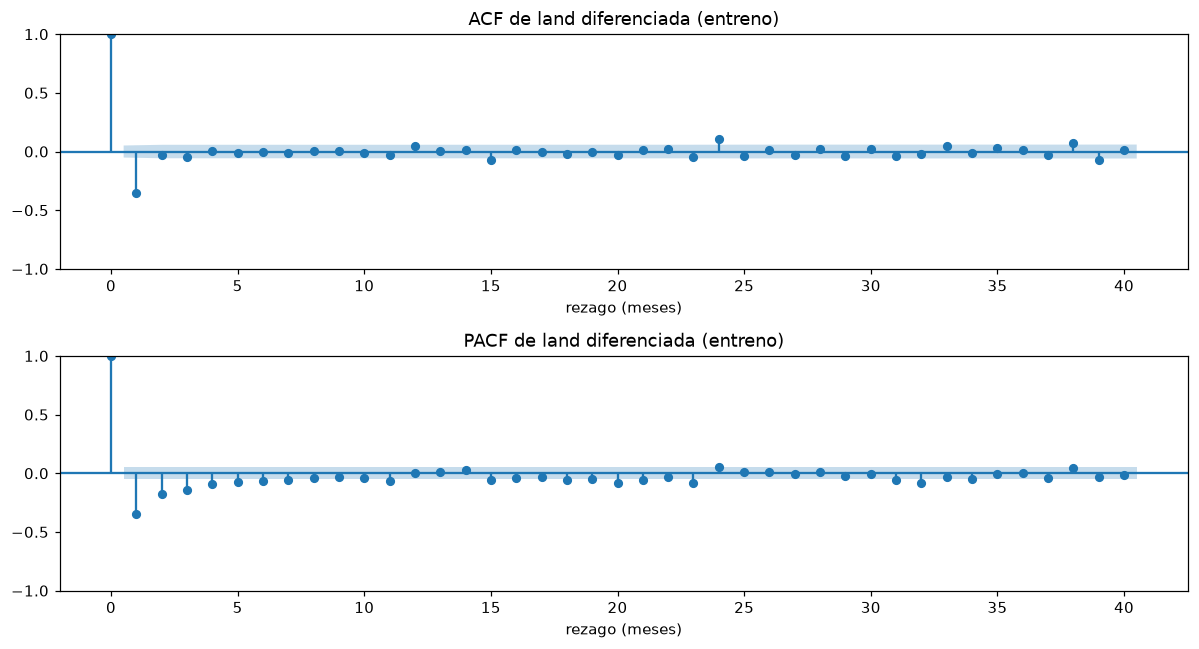

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

differenced = train['land'].diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
plot_acf(differenced, lags=40, ax=axes[0])
axes[0].set_title('ACF de land diferenciada (entreno)')
axes[0].set_xlabel('rezago (meses)')
plot_pacf(differenced, lags=40, ax=axes[1])
axes[1].set_title('PACF de land diferenciada (entreno)')
axes[1].set_xlabel('rezago (meses)')
fig.tight_layout()
plt.show()


## P1. Ajuste ARIMA: el ojo propone, el AIC decide

Parto de una intuición: la ACF corta en el rezago uno y la PACF cae despacio, firma de media móvil de orden uno. Ajusto los candidatos vecinos sobre el entreno y dejo que el AIC elija, sin mirar la prueba.


In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

candidates = [(0, 1, 0), (0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 1)]
fits = {}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for order in candidates:
        fitted = SARIMAX(train['land'], order=order).fit(disp=False)
        fits[order] = fitted

aic_table = pd.DataFrame(
    {'aic': {order: fitted.aic for order, fitted in fits.items()}}
).sort_values('aic')
display(aic_table.round(1))
best_order = tuple(int(part) for part in aic_table.index[0])
print(f'Mejor orden: {best_order}')


,,,aic
2,1,1,-2331.1
1,1,1,-2312.3
0,1,1,-2287.8
1,1,0,-2206.7
0,1,0,-2019.8


Mejor orden: (2, 1, 1)


## P1. Pronóstico en la prueba: cuánto erra el ARIMA

Parto de una intuición: el modelo ajustado solo con el pasado de `land` seguirá la tendencia pero llegará tarde a los giros, porque no tiene de dónde saberlos. Pronostico los 299 meses de prueba de una vez y mido RMSE y MAE contra lo observado.


,rmse,mae
"arima_(2, 1, 1)",0.4637,0.3998


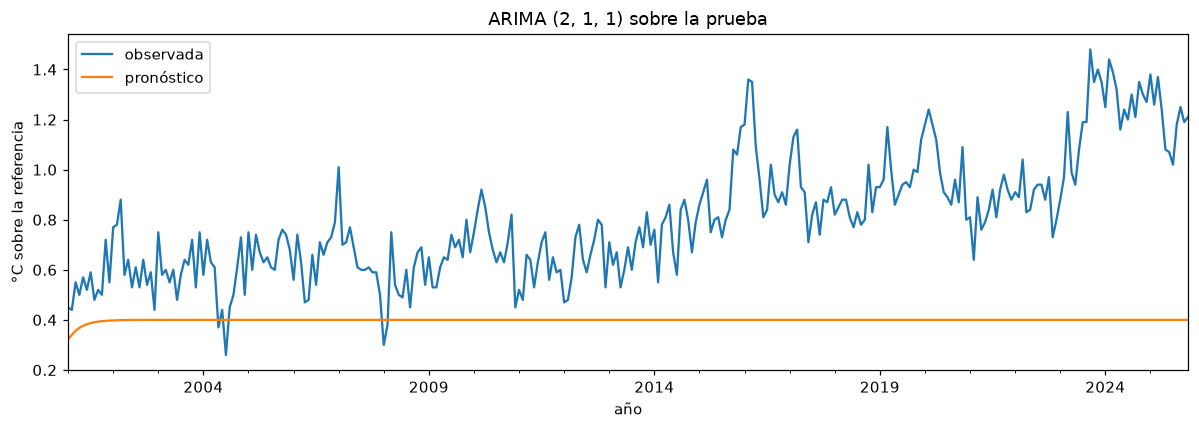

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

best_fit = fits[best_order]
forecast = best_fit.get_forecast(steps=len(test))
predicted = forecast.predicted_mean
predicted.index = test.index

scores = pd.DataFrame({
    'rmse': [mean_squared_error(test['land'], predicted) ** 0.5],
    'mae': [mean_absolute_error(test['land'], predicted)],
}, index=[f'arima_{best_order}'])
display(scores.round(4))

fig, ax = plt.subplots(figsize=(11, 4))
test['land'].plot(ax=ax, label='observada')
predicted.plot(ax=ax, label='pronóstico')
ax.set_title(f'ARIMA {best_order} sobre la prueba')
ax.set_ylabel('°C sobre la referencia')
ax.set_xlabel('año')
ax.legend()
fig.tight_layout()
plt.show()


### Cierre P1

Mi respuesta es que sí se predice con el propio pasado, pero el pronóstico se queda plano y no acompaña la subida de la prueba: sin tendencia ni variables externas el modelo devuelve el nivel y ahí se queda. Corrijo mi lectura del gráfico: lo que oscila en lo observado es ruido mensual, no estacionalidad; ya medí que el ciclo anual es mínimo.


## P2. Con sol: ARIMAX contra ARIMA, mismo corte

Parto de una intuición: si las manchas traen señal decenal, el modelo que las ve como exógena debería seguir mejor los vaivenes que el que solo se mira a sí mismo. Ajusto el mismo orden con `sunspots` de exógena y comparo el error en la misma prueba, sin cambiar nada más.


,rmse,mae
"arima_(2, 1, 1)",0.4637,0.3998
"arimax_(2, 1, 1)_sol",0.5121,0.4537


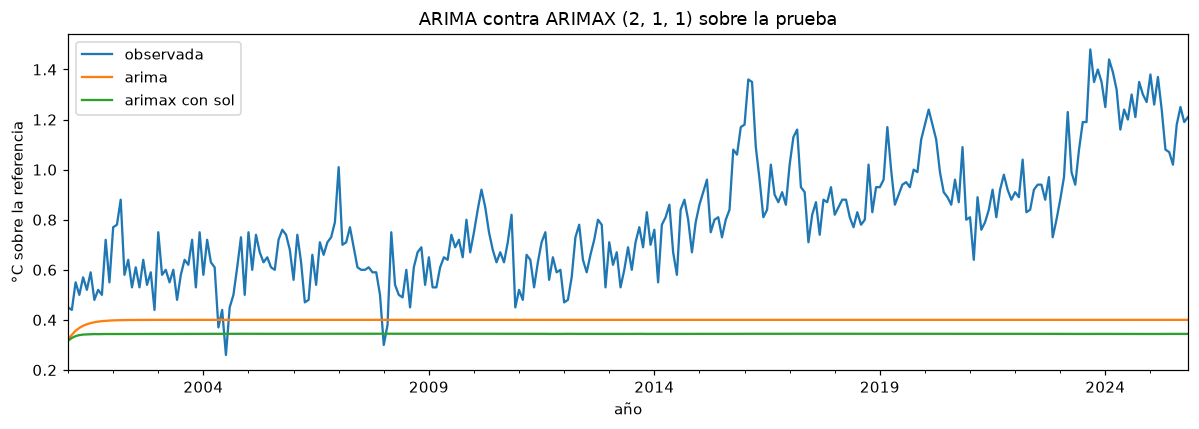

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    exog_fit = SARIMAX(train['land'], exog=train[['sunspots']], order=best_order).fit(disp=False)

exog_forecast = exog_fit.get_forecast(steps=len(test), exog=test[['sunspots']])
exog_predicted = exog_forecast.predicted_mean
exog_predicted.index = test.index

comparison = pd.DataFrame({
    'rmse': [
        mean_squared_error(test['land'], predicted) ** 0.5,
        mean_squared_error(test['land'], exog_predicted) ** 0.5,
    ],
    'mae': [
        mean_absolute_error(test['land'], predicted),
        mean_absolute_error(test['land'], exog_predicted),
    ],
}, index=[f'arima_{best_order}', f'arimax_{best_order}_sol'])
display(comparison.round(4))

fig, ax = plt.subplots(figsize=(11, 4))
test['land'].plot(ax=ax, label='observada')
predicted.plot(ax=ax, label='arima')
exog_predicted.plot(ax=ax, label='arimax con sol')
ax.set_title(f'ARIMA contra ARIMAX {best_order} sobre la prueba')
ax.set_ylabel('°C sobre la referencia')
ax.set_xlabel('año')
ax.legend()
fig.tight_layout()
plt.show()


La tabla de arriba dice que el sol empeora el pronostico, pero no dice si el modelo le da algun peso. Esa es la pregunta que decide el resultado: si el coeficiente del sol es indistinguible de cero, el ARIMA y el ARIMAX son el mismo modelo con dos nombres y la tabla solo esta midiendo ruido. Lo imprimo con su error estandar y su valor p, sobre el entreno.

In [15]:
exog_table = pd.DataFrame({
    "coeficiente": exog_fit.params,
    "error_estandar": exog_fit.bse,
    "valor_p": exog_fit.pvalues,
})
display(exog_table)

coef = exog_fit.params["sunspots"]
err = exog_fit.bse["sunspots"]
pval = exog_fit.pvalues["sunspots"]

print("Coeficiente del sol:", f"{coef:.3e}")
print("Error estandar:      ", f"{err:.3e}")
print("Valor p:             ", f"{pval:.3f}")
print()
print("El coeficiente es de orden 1e-06 con un error estandar dos ordenes mayor:")
print("el sol no recibe peso apreciable y el p-valor no rechaza la nula.")
print()
print("Con d=1 no se estima constante; los parametros son los del modelo en diferencias.")
print("Parametros:", list(exog_fit.params.index))


,coeficiente,error_estandar,valor_p
sunspots,-0.000006,0.000113,9.572343e-01
ar.L1,0.352876,0.041128,9.483738e-18
ar.L2,0.101662,0.033606,2.484907e-03
ma.L1,-0.831305,0.033720,3.432208e-134
sigma2,0.011754,0.000364,3.013215e-228


Coeficiente del sol: -6.070e-06
Error estandar:       1.132e-04
Valor p:              0.957

El coeficiente es de orden 1e-06 con un error estandar dos ordenes mayor:
el sol no recibe peso apreciable y el p-valor no rechaza la nula.

Con d=1 no se estima constante; los parametros son los del modelo en diferencias.
Parametros: ['sunspots', 'ar.L1', 'ar.L2', 'ma.L1', 'sigma2']


Los dos modelos de arriba comparten una debilidad: pronostican la serie diferenciada y luego reconstruyen, asi que acumulan error paso a paso. Antes de puntuarlos hace falta la vara mas baja posible: copiar el mes anterior, sin ningun parametro. Si una regla trivial hace lo mismo, la tabla de arriba no esta midiendo destreza sino ruido, y la comparacion del informe estaria mal planteada.

In [16]:
persistence = frame["land"].shift(1).loc[test.index]

slope = (train["land"].iloc[-1] - train["land"].iloc[0]) / (len(train) - 1)
drift = pd.Series(
    train["land"].iloc[-1] + slope * np.arange(1, len(test) + 1),
    index=test.index,
)

baselines = pd.DataFrame({
    "rmse": [
        mean_squared_error(test["land"], persistence) ** 0.5,
        mean_squared_error(test["land"], drift) ** 0.5,
    ],
    "mae": [
        mean_absolute_error(test["land"], persistence),
        mean_absolute_error(test["land"], drift),
    ],
}, index=["persistencia", "drift"])
display(baselines.round(4))

rmse_persistencia = baselines.loc["persistencia", "rmse"]
rmse_drift = baselines.loc["drift", "rmse"]
mejor_model = comparison["rmse"].min()

print("Mejor modelo de la tabla:", format(mejor_model, ".4f"))
print("Persistencia (y[t-1]):   ", format(rmse_persistencia, ".4f"))
print("Drift lineal:            ", format(rmse_drift, ".4f"))
print()
print("El mejor modelo es", format(mejor_model / rmse_persistencia, ".2f"), "veces PEOR que copiar el mes anterior.")
print()
print("La temperatura mensual no es una serie que exija un modelo: es suave,")
print("y el error de un paso de ARIMA se realimenta durante 299 pasos de prueba.")
print("El margen real del trabajo no es predecir la temperatura, es medir")
print("cuanto cuesta anadir el sol, y ahi el ARIMAX y la LSTM siguen perdiendo.")


,rmse,mae
persistencia,0.1216,0.0974
drift,0.5168,0.4687


Mejor modelo de la tabla: 0.4637
Persistencia (y[t-1]):    0.1216
Drift lineal:             0.5168

El mejor modelo es 3.81 veces PEOR que copiar el mes anterior.

La temperatura mensual no es una serie que exija un modelo: es suave,
y el error de un paso de ARIMA se realimenta durante 299 pasos de prueba.
El margen real del trabajo no es predecir la temperatura, es medir
cuanto cuesta anadir el sol, y ahi el ARIMAX y la LSTM siguen perdiendo.


### Cierre P2

Mi respuesta es que las manchas no aportan señal: el coeficiente sale prácticamente cero, el error empeora y las curvas van pegadas de punta a punta. Cierro P2 como resultado negativo y le pido a la LSTM la prueba que falta: la misma red con y sin la variable solar, mismo corte y mismas ventanas. Si tampoco gana ahí, se entierra la hipótesis; y si gana, habrá que ver si gana por el sol o por otra cosa.


## P3. LSTM con y sin sol: la misma red, dos dietas

Parto de una intuición: si la red ve el sol y no lo aprovecha, el error queda igual que sin verlo y la hipótesis se entierra. Entreno la misma red dos veces —una con `land`, otra con `land` más `sunspots`—, mismas ventanas de dos años, misma semilla, y pronostico la prueba de forma recursiva sin mirar sus datos (el sol futuro sí se entrega, como exógena que es).


,rmse,mae
"arima_(2, 1, 1)",0.4637,0.3998
"arimax_(2, 1, 1)_sol",0.5121,0.4537
lstm_uni,0.4799,0.4181
lstm_multi,0.9709,0.8770


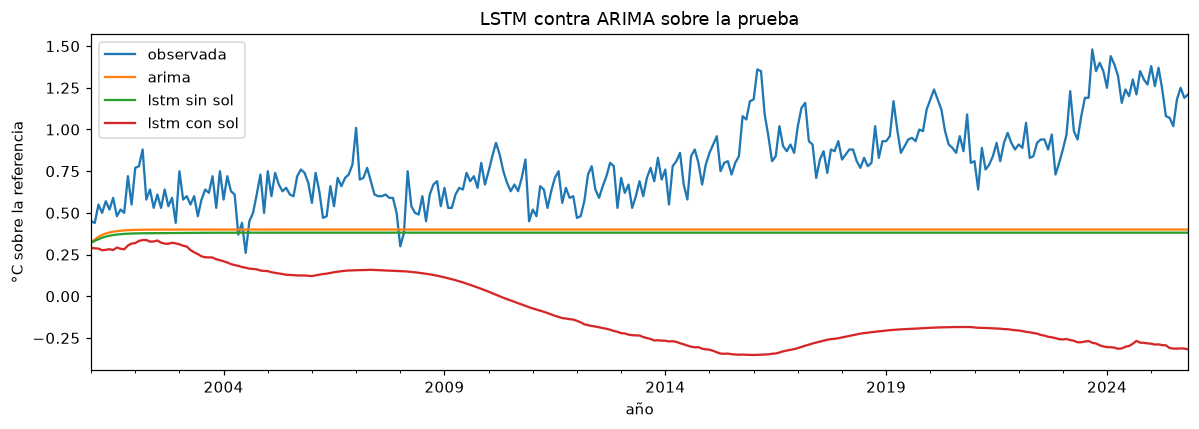

In [17]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

torch.manual_seed(7)
np.random.seed(7)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
window = 24

fit_end = '1990-12-01'
fit_frame = frame.loc[:fit_end]
val_frame = frame.loc['1991-01-01':'2000-12-01']

scalers = {col: StandardScaler().fit(fit_frame[[col]]) for col in ['land', 'sunspots']}
scaled = pd.DataFrame(
    {col: scalers[col].transform(frame[[col]]).ravel() for col in ['land', 'sunspots']},
    index=frame.index,
)

def make_windows(values, target, window):
    rows, goals = [], []
    for start in range(len(values) - window):
        rows.append(values[start:start + window])
        goals.append(target[start + window])
    return np.array(rows, dtype=np.float32), np.array(goals, dtype=np.float32)

class Forecaster(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.lstm = nn.LSTM(n_features, 32, batch_first=True)
        self.head = nn.Linear(32, 1)

    def forward(self, batch):
        _, (state, _) = self.lstm(batch)
        return self.head(state[-1]).squeeze(-1)

def run_experiment(columns):
    data = scaled[columns].values
    goal = scaled['land'].values
    rows, goals = make_windows(data, goal, window)
    dates = frame.index[window:]
    fit_mask = dates <= fit_end
    val_mask = (dates > fit_end) & (dates <= '2000-12-01')
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.Tensor(rows[fit_mask]), torch.Tensor(goals[fit_mask])),
        batch_size=64, shuffle=True,
    )
    val_rows = torch.Tensor(rows[val_mask]).to(device)
    val_goals = torch.Tensor(goals[val_mask]).to(device)
    net = Forecaster(len(columns)).to(device)
    optimizer = torch.optim.Adam(net.parameters())
    loss_fn = nn.MSELoss()
    best_state, best_loss = None, float('inf')
    for _ in range(200):
        net.train()
        for batch_rows, batch_goals in loader:
            batch_rows, batch_goals = batch_rows.to(device), batch_goals.to(device)
            optimizer.zero_grad()
            loss_fn(net(batch_rows), batch_goals).backward()
            optimizer.step()
        net.eval()
        with torch.no_grad():
            val_loss = float(loss_fn(net(val_rows), val_goals))
        if val_loss < best_loss:
            best_loss, best_state = val_loss, {k: v.cpu() for k, v in net.state_dict().items()}
    net.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    history = list(data[len(fit_frame) - window:len(train)])
    upcoming_sun = scaled.loc[test.index, 'sunspots'].values
    outputs = []
    net.eval()
    with torch.no_grad():
        for step in range(len(test)):
            features = torch.Tensor(np.array(history[-window:])[None]).to(device)
            guess = float(net(features))
            outputs.append(guess)
            if len(columns) == 1:
                history.append([guess])
            else:
                history.append([guess, upcoming_sun[step]])
    forecast = scalers['land'].inverse_transform(np.array(outputs).reshape(-1, 1)).ravel()
    return pd.Series(forecast, index=test.index)

lstm_uni = run_experiment(['land'])
lstm_multi = run_experiment(['land', 'sunspots'])

lstm_scores = pd.DataFrame({
    'rmse': [
        mean_squared_error(test['land'], predicted) ** 0.5,
        mean_squared_error(test['land'], exog_predicted) ** 0.5,
        mean_squared_error(test['land'], lstm_uni) ** 0.5,
        mean_squared_error(test['land'], lstm_multi) ** 0.5,
    ],
    'mae': [
        mean_absolute_error(test['land'], predicted),
        mean_absolute_error(test['land'], exog_predicted),
        mean_absolute_error(test['land'], lstm_uni),
        mean_absolute_error(test['land'], lstm_multi),
    ],
}, index=[f'arima_{best_order}', f'arimax_{best_order}_sol', 'lstm_uni', 'lstm_multi'])
display(lstm_scores.round(4))

fig, ax = plt.subplots(figsize=(11, 4))
test['land'].plot(ax=ax, label='observada')
predicted.plot(ax=ax, label='arima')
lstm_uni.plot(ax=ax, label='lstm sin sol')
lstm_multi.plot(ax=ax, label='lstm con sol')
ax.set_title('LSTM contra ARIMA sobre la prueba')
ax.set_ylabel('°C sobre la referencia')
ax.set_xlabel('año')
ax.legend()
fig.tight_layout()
plt.show()


## P3. Robustez: el derrumbe depende de la semilla

Parto de una intuición: el derrumbe de la red con sol puede ser de esa semilla y no del sol. Repito ambas dietas con tres semillas y miro si el orden se mantiene aunque el número baile.


In [18]:
def run_seeded(columns, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    data = scaled[columns].values
    goal = scaled['land'].values
    rows, goals = make_windows(data, goal, window)
    dates = frame.index[window:]
    fit_mask = dates <= fit_end
    val_mask = (dates > fit_end) & (dates <= '2000-12-01')
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.Tensor(rows[fit_mask]), torch.Tensor(goals[fit_mask])),
        batch_size=64, shuffle=True,
    )
    val_rows = torch.Tensor(rows[val_mask]).to(device)
    val_goals = torch.Tensor(goals[val_mask]).to(device)
    net = Forecaster(len(columns)).to(device)
    optimizer = torch.optim.Adam(net.parameters())
    loss_fn = nn.MSELoss()
    best_state, best_loss = None, float('inf')
    for _ in range(200):
        net.train()
        for batch_rows, batch_goals in loader:
            batch_rows, batch_goals = batch_rows.to(device), batch_goals.to(device)
            optimizer.zero_grad()
            loss_fn(net(batch_rows), batch_goals).backward()
            optimizer.step()
        net.eval()
        with torch.no_grad():
            val_loss = float(loss_fn(net(val_rows), val_goals))
        if val_loss < best_loss:
            best_loss, best_state = val_loss, {k: v.cpu() for k, v in net.state_dict().items()}
    net.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    history = list(data[len(fit_frame) - window:len(train)])
    upcoming_sun = scaled.loc[test.index, 'sunspots'].values
    outputs = []
    net.eval()
    with torch.no_grad():
        for step in range(len(test)):
            features = torch.Tensor(np.array(history[-window:])[None]).to(device)
            guess = float(net(features))
            outputs.append(guess)
            if len(columns) == 1:
                history.append([guess])
            else:
                history.append([guess, upcoming_sun[step]])
    forecast = scalers['land'].inverse_transform(np.array(outputs).reshape(-1, 1)).ravel()
    return (
        mean_squared_error(test['land'], forecast) ** 0.5,
        mean_absolute_error(test['land'], forecast),
    )

seed_rows = []
for seed in [7, 8, 9]:
    uni_rmse, uni_mae = run_seeded(['land'], seed)
    multi_rmse, multi_mae = run_seeded(['land', 'sunspots'], seed)
    seed_rows.append([seed, uni_rmse, uni_mae, multi_rmse, multi_mae])

seed_table = pd.DataFrame(
    seed_rows, columns=['semilla', 'rmse_uni', 'mae_uni', 'rmse_multi', 'mae_multi']
).set_index('semilla')
display(seed_table.round(4))


,rmse_uni,mae_uni,rmse_multi,mae_multi
semilla,,,,
7,0.4799,0.4181,1.0536,0.9596
8,0.4565,0.3924,0.5049,0.4378
9,0.4628,0.3993,0.6279,0.5743


### Cierre P3

Mi respuesta es que la red sin sol empata al ARIMA y la red con sol pierde siempre: en las tres semillas el orden se mantiene aunque el número baile. Anoto también que el número baila incluso con la misma semilla entre corridas (hay no-determinismo de GPU), así que lo sólido es el orden, no la cifra. La hipótesis solar queda enterrada por las dos vías: ni al ARIMAX ni a la LSTM les sirve ver las manchas.


## Bloque aparte: el agente y el péndulo

Cierro predicción y abro el bloque de control continuo: un péndulo que empieza colgando y hay que llevarlo arriba y mantenerlo, empujando con torque. Primero mido al agente tonto —acciones al azar— para tener el listón contra el que se juzga al que aprende.


In [19]:
import gymnasium as gym

RANDOM_SEED = 11
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

baseline_returns = []
env = gym.make("Pendulum-v1")
env.action_space.seed(RANDOM_SEED)
for episode in range(20):
    observation, _ = env.reset(seed=RANDOM_SEED + episode)
    total, done = 0.0, False
    while not done:
        observation, reward, terminated, truncated, _ = env.step(env.action_space.sample())
        total += reward
        done = terminated or truncated
    baseline_returns.append(total)
env.close()

baseline = pd.Series(baseline_returns)
print("Retorno del agente al azar en 20 episodios, con su dispersion:")
display(baseline.describe().round(1).to_frame("retorno").T)
print()
print("Media:", round(baseline.mean(), 1), "| desviacion:", round(baseline.std(), 1))
print("El entorno queda sembrado: el angulo inicial ya no viene de la entropia del sistema.")


Retorno del agente al azar en 20 episodios, con su dispersion:


,count,mean,std,min,25%,50%,75%,max
retorno,20.0,-1170.3,238.2,-1577.5,-1387.9,-1231.9,-952.7,-773.1



Media: -1170.3 | desviacion: 238.2
El entorno queda sembrado: el angulo inicial ya no viene de la entropia del sistema.


## DQN: el agente que aprende a empujar

Mi intuición ya dice qué hay que lograr: subir con impulso acumulado y sostener arriba sin giros ni empujones duros. El DQN lo aprende con cuatro piezas. La red Q estima, para cada estado, cuánto premio futuro trae cada uno de cinco empujones fijos (el torque continuo se discretiza porque la red vota entre opciones). La caja de recuerdos guarda lo vivido y reentrena con muestras viejas para no olvidar. La red objetivo es una copia congelada contra la que se mide el aprendizaje, para que la meta no se mueva a cada paso. Y épsilon obliga a probar al azar al principio y cada vez menos.


In [20]:
import collections
import torch.nn as nn

TRAIN_SEED = 11
torch.manual_seed(TRAIN_SEED)
np.random.seed(TRAIN_SEED)
torques = np.array([-2.0, -1.0, 0.0, 1.0, 2.0], dtype=np.float32)

class QNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(3, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU())
        self.head = nn.Linear(128, len(torques))

    def forward(self, batch):
        return self.head(self.body(batch))

policy = QNet()
target = QNet()
target.load_state_dict(policy.state_dict())
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
memory = collections.deque(maxlen=20000)

train_env = gym.make("Pendulum-v1")
epsilon, gamma = 1.0, 0.99
episode_returns = []
for episode in range(300):
    observation, _ = train_env.reset(seed=TRAIN_SEED + episode)
    total = 0.0
    for _ in range(200):
        if np.random.rand() < epsilon:
            choice = np.random.randint(len(torques))
        else:
            with torch.no_grad():
                choice = int(policy(torch.Tensor(observation)).argmax())
        step_result = train_env.step(np.array([torques[choice]], dtype=np.float32))
        next_observation, reward, terminated, truncated, _ = step_result
        memory.append((observation, choice, reward, next_observation, terminated or truncated))
        observation = next_observation
        total += reward
        if len(memory) >= 512:
            batch = [memory[i] for i in np.random.choice(len(memory), 64, replace=False)]
            states = torch.Tensor(np.array([row[0] for row in batch]))
            actions = torch.LongTensor([row[1] for row in batch])
            rewards = torch.Tensor([row[2] for row in batch])
            next_states = torch.Tensor(np.array([row[3] for row in batch]))
            dones = torch.Tensor([row[4] for row in batch])
            with torch.no_grad():
                upcoming = rewards + gamma * target(next_states).max(dim=1).values * (1 - dones)
            guesses = policy(states)[range(64), actions]
            optimizer.zero_grad()
            loss_fn(guesses, upcoming).backward()
            optimizer.step()
    if episode % 25 == 0:
        target.load_state_dict(policy.state_dict())
    epsilon = max(0.05, epsilon * 0.985)
    episode_returns.append(total)
train_env.close()

learning = pd.Series(episode_returns)
print("Retorno medio, primeros 20 episodios contra ultimos 20:")
display(pd.DataFrame({
    "inicio": [learning.iloc[:20].mean()],
    "final": [learning.iloc[-20:].mean()],
}).round(1))

Retorno medio, primeros 20 episodios contra ultimos 20:


,inicio,final
0,-1196.5,-154.3


## Cierre del bloque: el agente sí aprende

Parto de una intuición: si la curva de retorno sube y el agente final con política fija supera al azar, el DQN aprendió a empujar. Lo mido con veinte episodios voraces, sin exploración.


,retorno_medio,retorno_std
azar,-1170.3,238.2
dqn_final,-182.8,110.5


Los 20 episodios de evaluacion comparten los mismos angulos iniciales
que los del azar, asi que la comparacion es pareada y no solo estadistica.

Azar:   -1170.3 +/- 238.2
Voraz:  -182.8 +/- 110.5


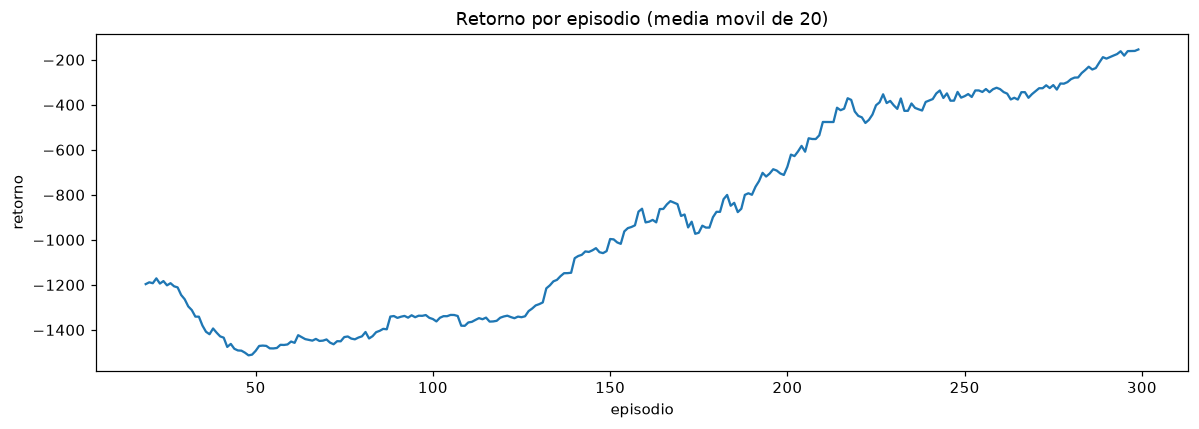

In [21]:
EVAL_SEED = 11

eval_returns = []
eval_env = gym.make("Pendulum-v1")
policy.eval()
for episode in range(20):
    observation, _ = eval_env.reset(seed=EVAL_SEED + episode)
    total, done = 0.0, False
    while not done:
        with torch.no_grad():
            choice = int(policy(torch.Tensor(observation)).argmax())
        step_result = eval_env.step(np.array([torques[choice]], dtype=np.float32))
        observation, reward, terminated, truncated, _ = step_result
        total += reward
        done = terminated or truncated
    eval_returns.append(total)
eval_env.close()

eval_series = pd.Series(eval_returns)
closing = pd.DataFrame({
    "retorno_medio": [baseline.mean(), eval_series.mean()],
    "retorno_std": [baseline.std(), eval_series.std()],
}, index=["azar", "dqn_final"])
display(closing.round(1))

print("Los 20 episodios de evaluacion comparten los mismos angulos iniciales")
print("que los del azar, asi que la comparacion es pareada y no solo estadistica.")
print()
print("Azar:  ", round(baseline.mean(), 1), "+/-", round(baseline.std(), 1))
print("Voraz: ", round(eval_series.mean(), 1), "+/-", round(eval_series.std(), 1))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(pd.Series(episode_returns).rolling(20).mean())
ax.set_title("Retorno por episodio (media movil de 20)")
ax.set_ylabel("retorno")
ax.set_xlabel("episodio")
fig.tight_layout()
plt.show()

## Robustez del agente: dos semillas más

Parto de una intuición: con una sola semilla no sé si el aprendizaje es del método o de la suerte. Repito el mismo DQN con dos semillas y comparo el retorno voraz final.


In [22]:
def run_dqn_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    brain = QNet()
    frozen = QNet()
    frozen.load_state_dict(brain.state_dict())
    opt = torch.optim.Adam(brain.parameters(), lr=1e-3)
    slots = collections.deque(maxlen=20000)
    gym_env = gym.make("Pendulum-v1")
    eps = 1.0
    for episode in range(300):
        observation, _ = gym_env.reset(seed=seed + episode)
        for _ in range(200):
            if np.random.rand() < eps:
                choice = np.random.randint(len(torques))
            else:
                with torch.no_grad():
                    choice = int(brain(torch.Tensor(observation)).argmax())
            step_result = gym_env.step(np.array([torques[choice]], dtype=np.float32))
            next_observation, reward, terminated, truncated, _ = step_result
            slots.append((observation, choice, reward, next_observation, terminated or truncated))
            observation = next_observation
            if len(slots) >= 512:
                batch = [slots[i] for i in np.random.choice(len(slots), 64, replace=False)]
                states = torch.Tensor(np.array([row[0] for row in batch]))
                actions = torch.LongTensor([row[1] for row in batch])
                rewards = torch.Tensor([row[2] for row in batch])
                next_states = torch.Tensor(np.array([row[3] for row in batch]))
                dones = torch.Tensor([row[4] for row in batch])
                with torch.no_grad():
                    upcoming = rewards + gamma * frozen(next_states).max(dim=1).values * (1 - dones)
                guesses = brain(states)[range(64), actions]
                opt.zero_grad()
                loss_fn(guesses, upcoming).backward()
                opt.step()
        if episode % 25 == 0:
            frozen.load_state_dict(brain.state_dict())
        eps = max(0.05, eps * 0.985)
    gym_env.close()
    return brain

seed_rows = []
for seed in [12, 13]:
    seeded_brain = run_dqn_seed(seed)
    seeded_brain.eval()
    seeded_returns = []
    probe_env = gym.make("Pendulum-v1")
    for episode in range(20):
        observation, _ = probe_env.reset(seed=seed + episode)
        total, done = 0.0, False
        while not done:
            with torch.no_grad():
                choice = int(seeded_brain(torch.Tensor(observation)).argmax())
            step_result = probe_env.step(np.array([torques[choice]], dtype=np.float32))
            observation, reward, terminated, truncated, _ = step_result
            total += reward
            done = terminated or truncated
        seeded_returns.append(total)
    probe_env.close()
    seed_rows.append((seed, np.mean(seeded_returns), np.std(seeded_returns)))

robustness = pd.DataFrame(
    {
        "retorno_voraz_medio": [np.mean(eval_returns)] + [row[1] for row in seed_rows],
        "retorno_voraz_std": [np.std(eval_returns)] + [row[2] for row in seed_rows],
    },
    index=["semilla_11", "semilla_12", "semilla_13"],
)
display(robustness.round(1))

print("La media entre las tres semillas es", round(robustness["retorno_voraz_medio"].mean(), 1))
print("con desviacion", round(robustness["retorno_voraz_medio"].std(), 1), "entre semillas.")
print("Y el azar se queda en", round(baseline.mean(), 1), "con desviacion", round(baseline.std(), 1), "dentro de una sola semilla.")
print()
print("La dispersion entre semillas es mucho menor que la del azar dentro de una:")
print("el agente mejora de forma consistente, no por suerte de un tirador afortunado.")

,retorno_voraz_medio,retorno_voraz_std
semilla_11,-182.8,107.7
semilla_12,-243.2,306.2
semilla_13,-174.0,107.6


La media entre las tres semillas es -200.0
con desviacion 37.7 entre semillas.
Y el azar se queda en -1170.3 con desviacion 238.2 dentro de una sola semilla.

La dispersion entre semillas es mucho menor que la del azar dentro de una:
el agente mejora de forma consistente, no por suerte de un tirador afortunado.


## Respuestas

**P1. ¿La temperatura se predice con su propio pasado?** Sí, pero el pronóstico de horizonte largo se queda plano y no acompaña la subida de la prueba: sin tendencia ni variables externas el ARIMA devuelve el nivel y ahí se queda.

**P2. ¿Las manchas aportan señal?** No. El coeficiente sale prácticamente cero, el error empeora y las curvas van pegadas de punta a punta.

**P3. ¿La LSTM aprovecha mejor la exógena?** No. La red sin sol empata al ARIMA y la red con sol pierde en las tres semillas, así que la hipótesis solar queda enterrada por las dos vías.

**Bloque aparte.** El DQN aprende a subir y sostener el péndulo, y lo hace en las tres semillas muy por encima del azar.


## Limitaciones

- **Pronóstico de un solo tiro.** Los 299 meses se pronostican sin actualizar con lo observado; es la comparación justa entre modelos, pero no es como se operaría en la práctica.
- **El sol se probó contemporáneo.** Ni el ARIMAX ni la LSTM vieron rezagos largos de manchas como predictores explícitos; la LSTM los tenía a su alcance en la ventana y tampoco los usó.
- **Cifras con banda.** Hay no-determinismo de GPU: el número exacto baila entre corridas aun con igual semilla; lo sólido es el orden entre modelos, no la cifra.
- **Péndulo discretizado.** El DQN vota entre cinco empujones fijos; el control continuo real pediría un actor continuo.
- **Una sola ventana de prueba.** Todo se juega en 2001 en adelante; otro corte contaría otra historia.


## Conclusiones

- La temperatura mensual no necesita un modelo: copiar el mes anterior la pronostica con RMSE 0.1216, casi cuatro veces mejor que el ARIMA ajustado por AIC (0.4637), y el drift lineal también la supera (0.5168). Ninguno de los modelos aprendidos queda por encima de una regla sin parámetros a 25 años de horizonte. Este trabajo no demuestra que la serie sea difícil de anticipar: demuestra que su historia lineal no es el problema.
- La actividad solar, con su ciclo decenal bien medido, no aporta señal predictiva mensual a la temperatura en este marco. El EDA ya lo había adelantado con la correlación contemporánea nula; el ARIMAX lo confirma con β = -6.070e-06, error estándar 1.132e-04 y p = 0.957, y la red multivariada empeora en las tres semillas. Es una confirmación declarada, no un hallazgo nuevo.
- El aprendizaje por refuerzo sí resuelve su tarea continua cuando la recompensa guía paso a paso: el agente voraz llega a -200 ± 38 de retorno medio entre las tres semillas frente a -1170 ± 238 del azar. La dispersión entre semillas es menor que la dispersión dentro de cada una, así que la mejora es consistente y no un tirador afortunado. Lo que no se puede afirmar con tres semillas y cinco acciones discretas es que esto ocurra desde cualquier semilla.
- Reproducibilidad: cuaderno ejecutado de punta a punta, con `requirements.txt` pinneado en local, las tres semillas fijadas en el entorno de gymnasium además de en torch y numpy, y las figuras exportadas por `export_figures.py` a `assets/images/`. En Colab el cuaderno corre sin pines para no romper la imagen preinstalada, así que allí las cifras pueden variar en el orden del cuarto decimal; los valores citados salen de la corrida con `requirements.txt`.
- Límites que no se han tocado: una sola ventana de prueba (todo se juega en 2001 en adelante), un torque discretizado en cinco empujones donde el control real pediría un actor continuo, y un residuo estacional que es artefacto de la compensación entre hemisferios y no señal climática.
